In [1]:
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)


2026-01-03 10:36:19.724352: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-03 10:36:19.827369: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1767411379.867241   11048 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1767411379.879453   11048 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1767411379.971515   11048 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [2]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))


[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import (
    Input, Conv1D, BatchNormalization,
    ReLU, Add, GlobalAveragePooling1D, Dense
)
from tensorflow.keras.models import Model



In [4]:
def tcn_block(x, filters, kernel_size, dilation):
    shortcut = x

    x = Conv1D(filters, kernel_size,
               padding="causal",
               dilation_rate=dilation)(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)

    x = Conv1D(filters, kernel_size,
               padding="causal",
               dilation_rate=dilation)(x)
    x = BatchNormalization()(x)

    if shortcut.shape[-1] != filters:
        shortcut = Conv1D(filters, 1, padding="same")(shortcut)

    x = Add()([x, shortcut])
    x = ReLU()(x)
    return x


In [5]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Dropout, MaxPooling1D, Flatten, Dense

def build_mr_tcn(input_shape=(64, 64), dropout_rate=0.00):
    model = Sequential()

    # Conv1D #1
    model.add(Conv1D(
        filters=64,
        kernel_size=3,
        strides=1,
        dilation_rate=1,
        padding="same",
        activation="relu",
        input_shape=input_shape
    ))
    model.add(Dropout(dropout_rate))

    # Conv1D #2
    model.add(Conv1D(
        filters=64,
        kernel_size=3,
        strides=1,
        dilation_rate=2,
        padding="same",
        activation="relu"
    ))
    model.add(Dropout(dropout_rate))

    # Conv1D #3
    model.add(Conv1D(
        filters=64,
        kernel_size=3,
        strides=1,
        dilation_rate=4,
        padding="same",
        activation="relu"
    ))
    model.add(Dropout(dropout_rate))

    # MaxPooling
    model.add(MaxPooling1D(pool_size=8, strides=8))

    # Flatten
    model.add(Flatten())

    # Dropout
    model.add(Dropout(dropout_rate))

    # Linear → Sigmoid
    model.add(Dense(1, activation="sigmoid"))

    return model


In [6]:
model = build_mr_tcn()

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()


/home/dani/miniconda3/envs/latihan1/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1767411382.865478   11048 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3601 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 64, 64)         │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 64, 64)         │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 64, 64)         │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 8, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 37,569 (146.75 KB)

 Trainable params: 37,569 (146.75 KB)

 Non-trainable params: 0 (0.00 B)

In [1]:
import numpy as np

def load_part_npz(path, normalize=True):
    data = np.load(path)
    X = data["X"]
    y = data["y"]


    return X, y


In [8]:
import os, gc, json
import numpy as np
from datetime import datetime

# =========================
# DIRECTORIES
# =========================
train_dir = "preprocessingW64S1binaryfloat32/train_parts/"
val_dir   = "preprocessingW64S1binaryfloat32/val_parts/"

train_files = sorted(os.listdir(train_dir))
val_files   = sorted(os.listdir(val_dir))

# =========================
# TRAINING PARAM
# =========================
GLOBAL_EPOCHS = 700
BATCH_SIZE = 64

# =========================
# EARLY STOPPING PARAM
# =========================
PATIENCE = 10          # berhenti jika tidak improve 10 global epoch
MIN_DELTA = 1e-3   # 0.001 # minimal penurunan val_loss agar dianggap improve

# =========================
# SAVE CONFIG
# =========================
SAVE_DIR = "saved_model_global"
os.makedirs(SAVE_DIR, exist_ok=True)

MODEL_LAST_PATH = os.path.join(SAVE_DIR, "000model_last.keras")
MODEL_BEST_PATH = os.path.join(SAVE_DIR, "000model_best.keras")
HISTORY_PATH    = os.path.join(SAVE_DIR, "000history.json")

# =========================
# HISTORY CONTAINER
# =========================
history = {
    "global_epoch": [],
    "train_loss": [],
    "val_loss": [],
    "val_acc": [],
    "timestamp": []
}

best_val_loss = np.inf
wait = 0   # counter early stopping


In [9]:
import tensorflow as tf

def log_current_device(tag=""):
    try:
        # ambil device dari weight pertama model
        device = model.trainable_variables[0].device
    except Exception:
        device = "UNKNOWN"

    if "GPU" in device.upper():
        print(f"🟢 [{tag}] TRAINING ON GPU → {device}")
    elif "CPU" in device.upper():
        print(f"🟡 [{tag}] TRAINING ON CPU → {device}")
    else:
        print(f"⚠️ [{tag}] DEVICE UNKNOWN → {device}")


In [10]:
def log_tf_devices(tag=""):
    gpus = tf.config.list_physical_devices('GPU')
    if gpus:
        print(f"🟢 [{tag}] TensorFlow sees GPU → {gpus}")
    else:
        print(f"🟡 [{tag}] TensorFlow uses CPU only")


In [11]:
log_tf_devices("Startup")



🟢 [Startup] TensorFlow sees GPU → [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [12]:
print("\n🔎 INITIAL DEVICE CHECK")
log_current_device(tag="Init")

for ge in range(GLOBAL_EPOCHS):
    print(f"\n🌍 Global Epoch {ge+1}/{GLOBAL_EPOCHS}")
    log_tf_devices("Startup")
    # ---------- TRAIN ----------
    train_losses = []   # ⬅️ reset tiap global epoch
    for fname in train_files:
        print(f"🚀 Training part {fname}")

        X_train, y_train = load_part_npz(
            os.path.join(train_dir, fname),
            normalize=True
        )

        history_part=model.fit(
            X_train,
            y_train,
            epochs=1,
            batch_size=BATCH_SIZE,
            shuffle=True,
            verbose=1
        )

        part_loss = history_part.history["loss"][-1]
        train_losses.append(part_loss)
        
        del X_train, y_train
        gc.collect()

    mean_train_loss = float(np.mean(train_losses))
    # ---------- VALIDATION ----------
    print("\n📊 Running validation on ALL parts...")

    val_losses = []
    val_accs   = []

    for vname in val_files:
        X_val, y_val = load_part_npz(
            os.path.join(val_dir, vname),
            normalize=True
        )

        loss, acc = model.evaluate(
            X_val,
            y_val,
            batch_size=BATCH_SIZE,
            verbose=0
        )

        val_losses.append(loss)
        val_accs.append(acc)

        del X_val, y_val
        gc.collect()

    mean_val_loss = float(np.mean(val_losses))
    mean_val_acc  = float(np.mean(val_accs))

    print(f"\n✅ VALIDATION RESULT - Global Epoch {ge+1}")
    print(f"   ➜ val_loss = {mean_val_loss:.6f}")
    print(f"   ➜ val_acc  = {mean_val_acc:.6f}")

    # ---------- DEVICE CHECK ----------
    log_current_device(tag=f"After Eval GE-{ge+1}")
    log_tf_devices("Startup")
    # ---------- SAVE HISTORY ----------
    history["global_epoch"].append(ge + 1)
    history["train_loss"].append(mean_train_loss)
    history["val_loss"].append(mean_val_loss)
    history["val_acc"].append(mean_val_acc)
    history["timestamp"].append(datetime.now().isoformat())

    with open(HISTORY_PATH, "w") as f:
        json.dump(history, f, indent=2)

    # ---------- SAVE LAST MODEL ----------
    model.save(MODEL_LAST_PATH)
    print(f"   ➜ train_loss = {mean_train_loss:.6f}")
    print(f"   ➜ val_loss   = {mean_val_loss:.6f}")



    # ---------- EARLY STOPPING LOGIC ----------
    if mean_val_loss < best_val_loss - MIN_DELTA:
        best_val_loss = mean_val_loss
        wait = 0
        model.save(MODEL_BEST_PATH)
        print("🏆 Best model updated!")
    else:
        wait += 1
        print(f"⏳ No improvement ({wait}/{PATIENCE})")

        if wait >= PATIENCE:
            print("\n🛑 EARLY STOPPING TRIGGERED")
            print(f"Best val_loss: {best_val_loss:.6f}")
            break
   
    tf.keras.backend.clear_session()


🔎 INITIAL DEVICE CHECK
⚠️ [Init] DEVICE UNKNOWN → UNKNOWN

🌍 Global Epoch 1/700
🟢 [Startup] TensorFlow sees GPU → [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
🚀 Training part train_part_001.npz


I0000 00:00:1767411384.505335   11715 service.cc:152] XLA service 0x7496dc00c2f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1767411384.505356   11715 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 3060 Laptop GPU, Compute Capability 8.6
2026-01-03 10:36:24.530013: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1767411384.681110   11715 cuda_dnn.cc:529] Loaded cuDNN version 91200


 90/155 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4622 - loss: 0.7146

I0000 00:00:1767411385.949944   11715 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


155/155 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.5046 - loss: 0.6993
🚀 Training part train_part_002.npz
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5910 - loss: 0.6794
🚀 Training part train_part_003.npz
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6403 - loss: 0.6671
🚀 Training part train_part_004.npz
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6809 - loss: 0.6549
🚀 Training part train_part_005.npz
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7175 - loss: 0.6416
🚀 Training part train_part_006.npz
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7463 - loss: 0.6278
🚀 Training part train_part_007.npz
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7746 - loss: 0.6103
🚀 Training part train_part_008.npz
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7962 - loss: 0.5944
🚀 Training part train_part_009.npz
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8186 - loss: 0.5710
🚀 Training part train_part_010.npz
155/155 ━━

In [2]:
from tensorflow.keras.models import load_model
import json

model = load_model("saved_model_global/000model_best.keras")

with open("saved_model_global/history.json", "r") as f:
    history = json.load(f)

print("✅ Model & history loaded")
print("Total epochs:", len(history["global_epoch"]))
print("Best val_loss:", min(history["val_loss"]))


2026-01-04 09:06:42.094154: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-04 09:06:42.103587: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1767492402.115002    7715 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1767492402.118853    7715 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1767492402.127706    7715 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

✅ Model & history loaded
Total epochs: 127
Best val_loss: 0.11014366272617789


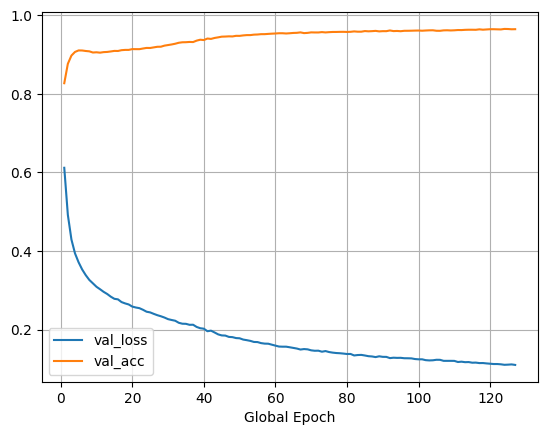

In [3]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(history["global_epoch"], history["val_loss"], label="val_loss")
plt.plot(history["global_epoch"], history["val_acc"], label="val_acc")
plt.xlabel("Global Epoch")
plt.legend()
plt.grid(True)
plt.show()


In [4]:
import numpy as np
import os

val_dir = "preprocessingW64S1binaryfloat32/val_parts/"
val_files = sorted(os.listdir(val_dir))

all_loss = []
all_acc  = []

for fname in val_files:
    X_val, y_val = load_part_npz(
        os.path.join(val_dir, fname),
        normalize=True
    )

    loss, acc = model.evaluate(
        X_val, y_val,
        batch_size=64,
        verbose=0
    )

    all_loss.append(loss)
    all_acc.append(acc)

    del X_val, y_val

print("\n📊 FINAL MODEL PERFORMANCE")
print("Mean val_loss :", np.mean(all_loss))
print("Mean val_acc  :", np.mean(all_acc))


I0000 00:00:1767492404.840155   26574 service.cc:152] XLA service 0x76a9340058f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1767492404.840171   26574 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 3060 Laptop GPU, Compute Capability 8.6
2026-01-04 09:06:44.850655: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1767492404.888317   26574 cuda_dnn.cc:529] Loaded cuDNN version 91200
I0000 00:00:1767492405.297161   26574 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.



📊 FINAL MODEL PERFORMANCE
Mean val_loss : 0.010019015876905006
Mean val_acc  : 0.9968845521702486


In [5]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

y_true_all = []
y_pred_all = []

THRESHOLD = 0.5  # bisa kamu optimasi pakai Youden/F1 sebelumnya

for fname in val_files:
    X_val, y_val = load_part_npz(
        os.path.join(val_dir, fname),
        normalize=True
    )

    y_prob = model.predict(X_val, batch_size=64, verbose=0).ravel()
    y_pred = (y_prob >= THRESHOLD).astype(int)

    y_true_all.append(y_val)
    y_pred_all.append(y_pred)

    del X_val, y_val

y_true_all = np.concatenate(y_true_all)
y_pred_all = np.concatenate(y_pred_all)


In [6]:
acc  = accuracy_score(y_true_all, y_pred_all)
prec = precision_score(y_true_all, y_pred_all)
rec  = recall_score(y_true_all, y_pred_all)
f1   = f1_score(y_true_all, y_pred_all)
cm   = confusion_matrix(y_true_all, y_pred_all)

print("\n📊 FINAL METRICS")
print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1-score  : {f1:.4f}")

print("\n🧮 Confusion Matrix")
print(cm)



📊 FINAL METRICS
Accuracy  : 0.9969
Precision : 0.9979
Recall    : 0.9964
F1-score  : 0.9971

🧮 Confusion Matrix
[[164617    410]
 [   715 195361]]


In [7]:
import os, gc, json
y_true_all = []
y_pred_all = []
y_prob_all = []

THRESHOLD = 0.5

for fname in val_files:
    X_val, y_val = load_part_npz(
        os.path.join(val_dir, fname),
        normalize=True
    )

    y_prob = model.predict(
        X_val,
        batch_size=64,
        verbose=0
    ).ravel()

    y_pred = (y_prob >= THRESHOLD).astype(int)

    y_true_all.append(y_val)
    y_pred_all.append(y_pred)
    y_prob_all.append(y_prob)

    del X_val, y_val
    gc.collect()

y_true_all = np.concatenate(y_true_all)
y_pred_all = np.concatenate(y_pred_all)
y_prob_all = np.concatenate(y_prob_all)


In [8]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score
)

acc  = accuracy_score(y_true_all, y_pred_all)
prec = precision_score(y_true_all, y_pred_all)
rec  = recall_score(y_true_all, y_pred_all)
f1   = f1_score(y_true_all, y_pred_all)
auc  = roc_auc_score(y_true_all, y_prob_all)

cm = confusion_matrix(y_true_all, y_pred_all)

print("\n📊 FINAL MODEL METRICS")
print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1-score  : {f1:.4f}")
print(f"ROC-AUC   : {auc:.4f}")

print("\n🧮 Confusion Matrix")
print(cm)



📊 FINAL MODEL METRICS
Accuracy  : 0.9969
Precision : 0.9979
Recall    : 0.9964
F1-score  : 0.9971
ROC-AUC   : 0.9999

🧮 Confusion Matrix
[[164617    410]
 [   715 195361]]


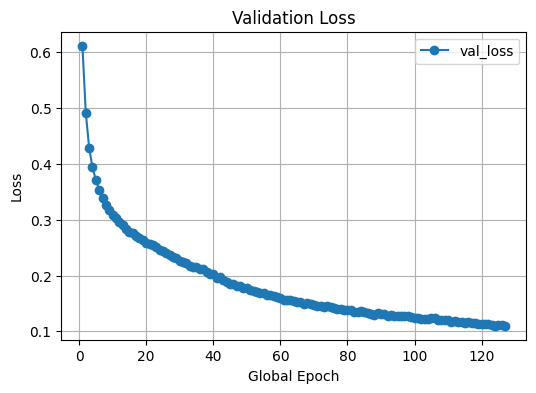

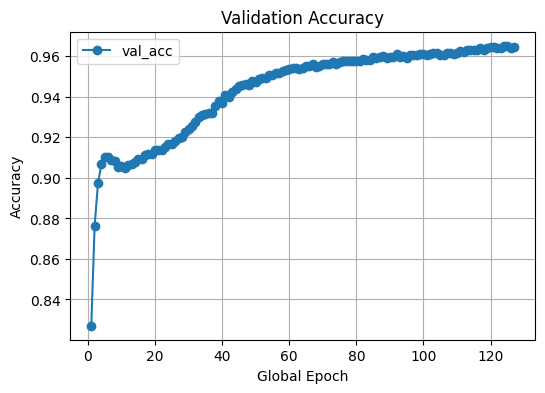

In [9]:
import matplotlib.pyplot as plt

epochs = history["global_epoch"]

plt.figure(figsize=(6,4))
plt.plot(epochs, history["val_loss"], marker="o", label="val_loss")
plt.xlabel("Global Epoch")
plt.ylabel("Loss")
plt.title("Validation Loss")
plt.grid(True)
plt.legend()
plt.show()


plt.figure(figsize=(6,4))
plt.plot(epochs, history["val_acc"], marker="o", label="val_acc")
plt.xlabel("Global Epoch")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy")
plt.grid(True)
plt.legend()
plt.show()


In [10]:
import os, gc
import numpy as np
from sklearn.metrics import roc_curve, confusion_matrix, classification_report

test_dir = "preprocessingW64S1binaryfloat32/test_parts/"
test_files = sorted(os.listdir(test_dir))

y_true_all = []
y_prob_all = []

for fname in test_files:
    X_test, y_test = load_part_npz(
        os.path.join(test_dir, fname),
        normalize=True
    )

    y_prob = model.predict(
        X_test,
        batch_size=64,
        verbose=0
    ).ravel()

    y_true_all.append(y_test)
    y_prob_all.append(y_prob)

    del X_test, y_test
    gc.collect()

y_true_all = np.concatenate(y_true_all)
y_prob_all = np.concatenate(y_prob_all)

print("Total test samples:", len(y_true_all))


Total test samples: 791548


In [11]:
fpr, tpr, thresholds = roc_curve(y_true_all, y_prob_all)

youden_index = tpr - fpr
best_threshold = thresholds[np.argmax(youden_index)]

print(f"🎯 Best threshold (Youden): {best_threshold:.6f}")


🎯 Best threshold (Youden): 0.899759


In [12]:
y_pred = (y_prob_all >= best_threshold).astype(int)

print("\n🧮 Confusion Matrix")
print(confusion_matrix(y_true_all, y_pred))

print("\n📊 Classification Report")
print(classification_report(
    y_true_all,
    y_pred,
    target_names=["Normal", "Attack"]
))



🧮 Confusion Matrix
[[428645   9425]
 [ 70476 283002]]

📊 Classification Report
              precision    recall  f1-score   support

      Normal       0.86      0.98      0.91    438070
      Attack       0.97      0.80      0.88    353478

    accuracy                           0.90    791548
   macro avg       0.91      0.89      0.90    791548
weighted avg       0.91      0.90      0.90    791548



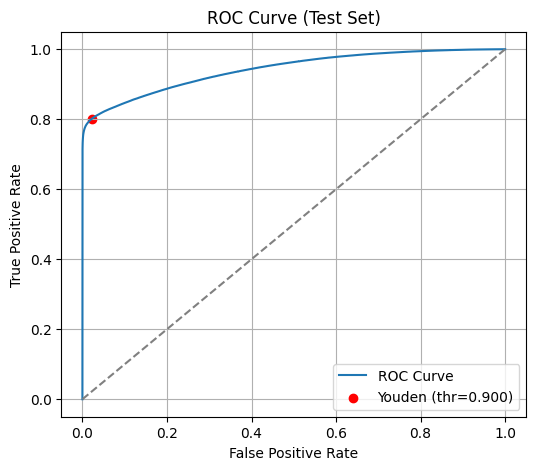

In [13]:
import matplotlib.pyplot as plt

best_idx = np.argmax(youden_index)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label="ROC Curve")
plt.scatter(
    fpr[best_idx],
    tpr[best_idx],
    color="red",
    label=f"Youden (thr={best_threshold:.3f})"
)
plt.plot([0,1], [0,1], "--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Test Set)")
plt.legend()
plt.grid(True)
plt.show()


In [14]:
import numpy as np
from sklearn.metrics import confusion_matrix

def compute_ids_metrics(y_true, y_pred):
    """
    Compute IDS metrics exactly as defined in IDS literature:
    Accuracy, F1-score, FPR, FNR
    """

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    acc = (tp + tn) / (tp + tn + fp + fn)
    f1  = (2 * tp) / (2 * tp + fp + fn)
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0.0

    return {
        "TP": tp,
        "FP": fp,
        "TN": tn,
        "FN": fn,
        "Accuracy": acc,
        "F1-score": f1,
        "FPR": fpr,
        "FNR": fnr,
    }


In [15]:
metrics = compute_ids_metrics(y_true_all, y_pred)

for k, v in metrics.items():
    print(f"{k:10s}: {v:.6f}" if isinstance(v, float) else f"{k:10s}: {v}")


TP        : 283002
FP        : 9425
TN        : 428645
FN        : 70476
Accuracy  : 0.899057
F1-score  : 0.876296
FPR       : 0.021515
FNR       : 0.199379
